## the only parameters i need 
1) max_depth → Limits how deep the tree can grow. Controls complexity and prevents overfitting.

2) min_samples_split → Minimum number of samples required to split a node. Larger values make the tree less complex.

3) min_samples_leaf → Minimum number of samples required in a leaf node. Prevents tiny leaves that overfit.

4) max_features → Number of features to consider when looking for the best split. Useful for ensembles like Random Forests.

5) criterion → The function used to measure split quality ("gini" or "entropy").
7) random_state → Ensures reproducibility.

8) class_weight → Helps handle imbalanced datasets.

9) max_leaf_nodes → Limits the number of leaf nodes directly.

In [87]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
data = pd.read_csv(r"C:\Users\pc\Downloads\Titanic-Dataset.csv")
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [88]:
data.isnull().sum()
data["Age"].fillna(data["Age"].mean(),inplace = True)
data

C:\Users\pc\AppData\Local\Temp\ipykernel_13120\3564755852.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].mean(),inplace = True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


In [89]:
data["Sex"] = data["Sex"].replace({'male':1,'female':0})
data = data.drop(columns=['Ticket','Name','PassengerId','Cabin'])
data

C:\Users\pc\AppData\Local\Temp\ipykernel_13120\1644221233.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Sex"] = data["Sex"].replace({'male':1,'female':0})


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.000000,1,0,7.2500,S
1,1,1,0,38.000000,1,0,71.2833,C
2,1,3,0,26.000000,0,0,7.9250,S
3,1,1,0,35.000000,1,0,53.1000,S
4,0,3,1,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,S
887,1,1,0,19.000000,0,0,30.0000,S
888,0,3,0,29.699118,1,2,23.4500,S
889,1,1,1,26.000000,0,0,30.0000,C


In [90]:
from sklearn.model_selection import train_test_split
y =  data.iloc[:,0]
X = data.iloc[:,1:7]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2 ,random_state= 2)

In [91]:
model = DecisionTreeClassifier(max_depth= 10)

In [92]:
model.fit(X_train,y_train)
pred = model.predict(X_test)

In [93]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

0.7988826815642458

In [94]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7988826815642458
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.89      0.83       100
           1       0.83      0.68      0.75        79

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix:
 [[89 11]
 [25 54]]


In [101]:
train_scores = []
test_scores = []
for t in range(1,21):
    model = DecisionTreeClassifier(random_state= 42,max_depth= t)
    model.fit(X_train,y_train)

    train_p = model.predict(X_train)
    train_a = accuracy_score(y_train,train_p)
    train_scores.append(train_a)

    test_p = model.predict(X_test)
    test_a = accuracy_score(y_test,test_p)
    test_scores.append(test_a)

    

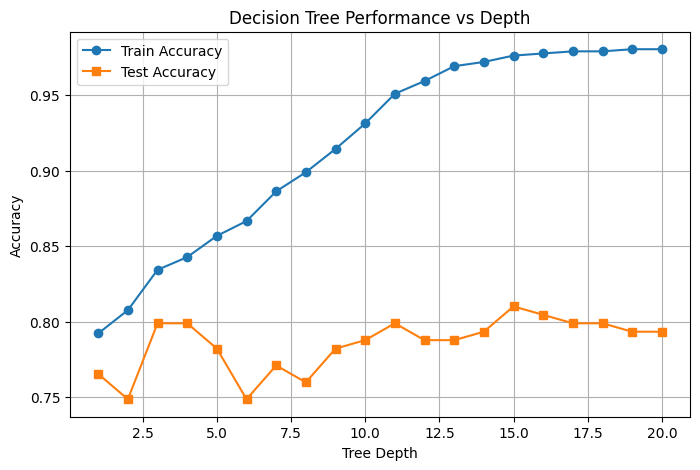

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 21), train_scores, label="Train Accuracy", marker='o')
plt.plot(range(1, 21), test_scores, label="Test Accuracy", marker='s')
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Performance vs Depth")
plt.legend()
plt.grid(True)
plt.show()

In [104]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(1,21),
    'min_samples_leaf': range(1,21),
    'min_samples_split': range(1,21)
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
0.8272431793558555


c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
2000 fits failed out of a total of 40000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2000 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\User

In [110]:
best_model = DecisionTreeClassifier(max_depth=3,min_samples_leaf=5,min_samples_split=2)
best_model.fit(X_train,y_train)
pred = best_model.predict(X_test)
pred
accuracy_score(y_test,pred)

0.7988826815642458

In [115]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 10, 20]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)
n_p = grid.predict(X_test)
print(" Model accuracy : " , accuracy_score(y_test,n_p))

{'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
0.8272333300502315
 Model accuracy :  0.7988826815642458
